In [1]:
from itertools import product
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

from confrdm_jax.simulators import simulate_crdm_dataset


I0000 00:00:1782058223.562958   35934 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782058223.563392   35934 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782058224.583213   35934 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782058224.583509   35934 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
def create_delta_plot(data, ax):
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    qs = np.linspace(0, 1, 9)[1:-1]

    mean_quantiles = np.array(
        [
            stats.mstats.mquantiles(
                rt[np.bitwise_and(resp == 1, cond == i)],
                qs,
                alphap=0.5,
                betap=0.5,
            )
            for i in (0, 1)
        ],
    )

    diff_quantiles = mean_quantiles[0, :] - mean_quantiles[1, :]

    ax.plot(mean_quantiles.mean(axis=0), diff_quantiles, "--o", color="black")


def create_caf_plot(data, ax, n_bins=5):
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    color_dict = {
        0: "#8B1A1A",
        1: "#1B4F8A",
    }

    for i in np.unique(cond):
        # Select data for this condition
        mask = cond == i
        rt_cond = rt[mask]
        resp_cond = resp[mask]
        # Bin RTs for this condition
        bins = np.quantile(rt_cond, np.linspace(0, 1, n_bins + 1))
        bin_indices = np.digitize(rt_cond, bins, right=True) - 1
        # Ensure bin_indices are within range
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)
        prop_resp = []
        bin_centers = []
        for b in range(n_bins):
            in_bin = bin_indices == b
            if np.any(in_bin):
                prop = resp_cond[in_bin].mean()
                center = rt_cond[in_bin].mean()
            else:
                prop = np.nan
                center = np.nan
            prop_resp.append(prop)
            bin_centers.append(center)
        ax.plot(range(1, n_bins + 1), prop_resp, marker="o", linestyle="-", color=color_dict[i])


def create_quantile_plot(data, ax):
    rt = data[:, 0]
    cond = data[:, 2]

    color_dict = {
        0: "#8B1A1A",
        1: "#1B4F8A",
    }

    for i in np.unique(cond):
        # Select data for this condition
        mask = cond == i
        rt_cond = rt[mask]
        # Bin RTs for this condition
        ax.ecdf(rt_cond, linestyle="-", color=color_dict[i])

In [3]:
def simulate_crdm_dataset_conditions(
    key: jnp.ndarray,
    batch_shape: tuple[int, ...],
    v_c_intercept: jnp.ndarray,
    v_c_slope: jnp.ndarray,
    amp: jnp.ndarray,
    tau: jnp.ndarray,
    s_true: jnp.ndarray,
    b: jnp.ndarray,
    t0: jnp.ndarray,
    dt: float,
    t_max: float,
):

    key_data_con, key_data_inc = jax.random.split(key, 2)

    condition = jnp.ones(batch_shape)
    condition = jnp.expand_dims(condition.at[(batch_shape[0] // 2):].set(0), -1)

    data_shape = (batch_shape[0] // 2,)

    keys_con = jax.random.split(key_data_con, data_shape)

    x_con = simulate_crdm_dataset(
        keys_con,
        v_c_intercept,
        v_c_slope,
        amp,
        tau,
        s_true,
        b,
        t0,
        dt,
        t_max,
    )

    keys_inc = jax.random.split(key_data_inc, data_shape)

    x_inc = simulate_crdm_dataset(
        keys_inc,
        v_c_intercept,
        v_c_slope,
        -amp,
        tau,
        s_true,
        b,
        t0,
        dt,
        t_max,
    )

    return jnp.c_[jnp.concatenate([x_con, x_inc]), condition]

In [4]:
plt.rcParams.update({
    "font.family":         "sans-serif",
    "font.size":           12,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.labelsize":      12,
    "legend.fontsize":     10,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
})

/tmp/ipykernel_35934/3171520001.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


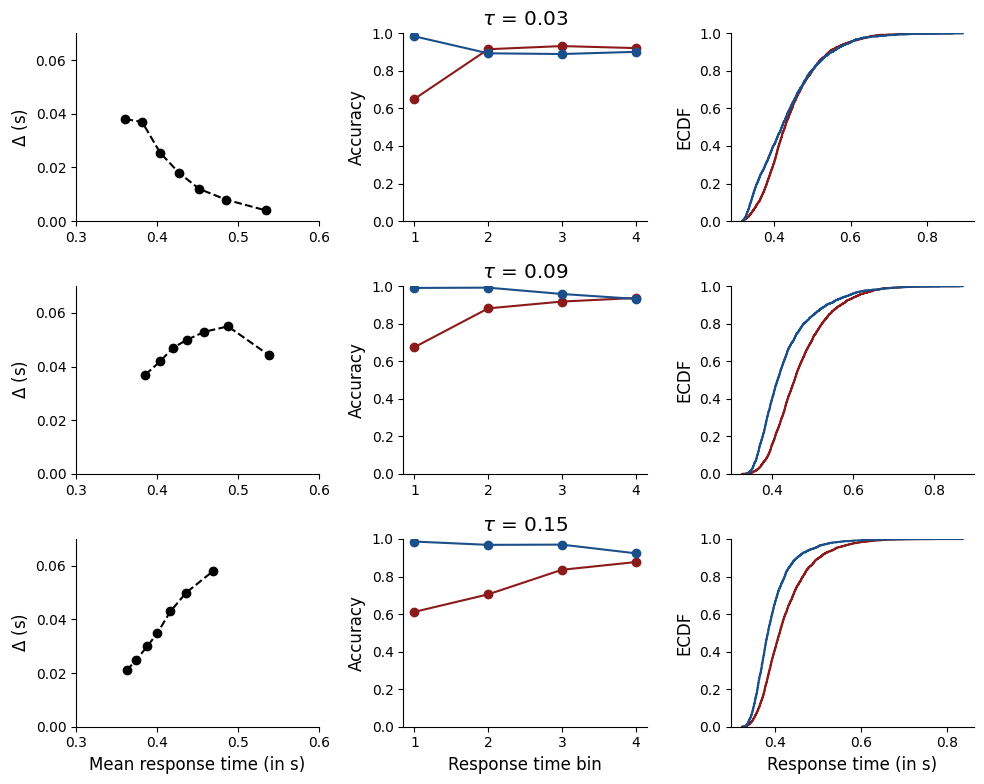

In [7]:
NUM_TRIALS = 5000
DT = 0.001
T_MAX = 4.0

main_key = jax.random.key(2026)

params = [
    {"v_c_slope": 4.0, "tau": 0.03, "b": 0.7},
    {"v_c_slope": 4.5, "tau": 0.09, "b": 0.9},
    {"v_c_slope": 4.5, "tau": 0.15, "b": 0.7},
]

fig, axarr = plt.subplots(len(params), 3, figsize=(10, 8))

for i, (p, axrow) in enumerate(zip(params, axarr)):
    tau = p["tau"]

    data = simulate_crdm_dataset_conditions(
        main_key,
        (NUM_TRIALS,),
        v_c_intercept=0.5,
        v_c_slope=p["v_c_slope"],
        amp=0.3,
        tau=tau,
        s_true=0.9,
        b=p["b"],
        t0=0.3,
        dt=DT,
        t_max=T_MAX,
    )

    create_delta_plot(data, axrow[0])
    create_caf_plot(data, axrow[1], n_bins=4)
    create_quantile_plot(data, axrow[2])

    
    axrow[1].set_title(rf"$\tau$ = {tau}")

    axrow[0].set_xlim((0.3, 0.6))
    axrow[0].set_ylim((0, 0.07))
    axrow[0].set_ylabel(r"$\Delta$ (s)")
    if i == 2:
        axrow[0].set_xlabel("Mean response time (in s)")
    axrow[1].set_ylim((0, 1))
    axrow[1].set_ylabel("Accuracy")
    if i == 2:
        axrow[1].set_xlabel("Response time bin")
    axrow[2].set_ylabel("ECDF")
    if i == 2:
        axrow[2].set_xlabel("Response time (in s)")

fig.tight_layout()
fig.savefig("crdm_phenomena.png", dpi=150, bbox_inches='tight')
fig.show()